# 🏥 Healthcare ML Platform
## Notebook 03 — Feature Engineering Pipeline

**Input:**  `data/processed/pima_clean.csv`  
**Output:** `data/processed/pima_features.csv` — model-ready dataset

### What is feature engineering?
Raw data is rarely in the best shape for a model to learn from.  
Feature engineering means transforming and enriching the data so patterns  
become clearer and the model can learn more effectively.

### What this notebook does
1. Creates new features from existing columns
2. Encodes categorical columns into numbers
3. Scales all numeric features to the same range
4. Splits data into train and test sets
5. Saves the final model-ready dataset

---
> All future model notebooks (04 onwards) load from  
> `data/processed/pima_features.csv` — not the raw or cleaned CSV.

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import joblib
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print("✓ Libraries ready")

✓ Libraries ready


---
## Step 1 — Load the Cleaned Data

We load `pima_clean.csv` — the output of Notebook 01.  
This file already has:
- Zeros replaced with NaN
- NaN filled with column medians
- All 768 rows intact


In [32]:
df = pd.read_csv('G:\healthcare\Dataset\processed\pima_clean.csv')

print(f"Shape   : {df.shape}")
print(f"Columns : {list(df.columns)}")
print(f"\nFirst 3 rows:")
df.head(3)

Shape   : (768, 9)
Columns : ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

First 3 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.00000,155.548223,33.6,0.627,50,1
1,1,85.0,66.0,29.00000,155.548223,26.6,0.351,31,0
2,8,183.0,64.0,29.15342,155.548223,23.3,0.672,32,1


---
## Step 2 — Create New Features

We create 4 new columns from existing ones.  
Each one encodes a clinically meaningful grouping  
that the model can learn from more easily than raw numbers.

| New column | Built from | Why |
|---|---|---|
| `BMI_category` | BMI | Underweight / Normal / Overweight / Obese |
| `Age_group` | Age | Young / Middle / Senior |
| `Glucose_level` | Glucose | Normal / Prediabetic / Diabetic |
| `Risk_score` | Multiple columns | Composite 0–100 risk indicator |

**Important:** We keep the original columns too.  
The model gets both the raw number AND the category .

BMI category distribution:
BMI_category
Obese          483
Overweight     179
Normal         102
Underweight      4
Name: count, dtype: int64



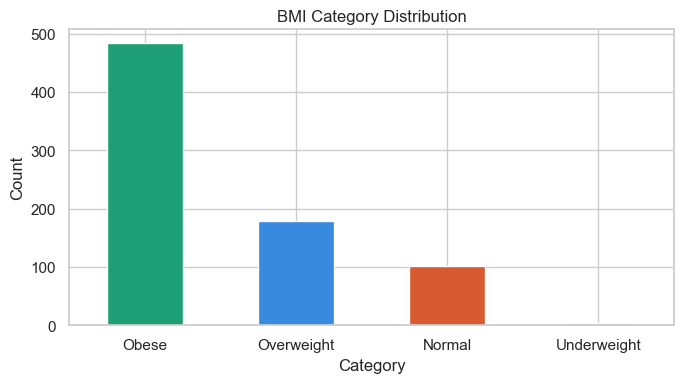

✓ BMI_category column created


In [33]:
# Clinical BMI categories from WHO standard
def bmi_category(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25.0:
        return 'Normal'
    elif bmi < 30.0:
        return 'Overweight'
    else:
        return 'Obese'

df['BMI_category'] = df['BMI'].apply(bmi_category)

print("BMI category distribution:")
print(df['BMI_category'].value_counts())
print()

# Visualise
df['BMI_category'].value_counts().plot(
    kind='bar', color=['#1D9E75','#378ADD','#D85A30','#7F77DD'],
    edgecolor='white', figsize=(7, 4)
)
plt.title('BMI Category Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/bmi_categories.png', dpi=150)
plt.show()
print("✓ BMI_category column created")

In [34]:
def age_group(age):
    if age <= 30:
        return 'Young'
    elif age <= 50:
        return 'Middle'
    else:
        return 'Senior'

df['Age_group'] = df['Age'].apply(age_group)

print("Age group distribution:")
print(df['Age_group'].value_counts())
print()

# How does age group relate to diabetes outcome?
pd.crosstab(df['Age_group'], df['Outcome'],
            normalize='index').round(2).mul(100)

Age group distribution:
Age_group
Young     417
Middle    270
Senior     81
Name: count, dtype: int64



Outcome,0,1
Age_group,,
Middle,48.0,52.0
Senior,53.0,47.0
Young,78.0,22.0


Middle aged and Senior patients have noticeably higher diabetes rate

In [35]:
# Clinical glucose thresholds from American Diabetes Association
def glucose_level(glucose):
    if glucose < 100:
        return 'Normal'
    elif glucose < 126:
        return 'Prediabetic'
    else:
        return 'Diabetic_range'

df['Glucose_level'] = df['Glucose'].apply(glucose_level)

print("Glucose level distribution:")
print(df['Glucose_level'].value_counts())
print()

# Crosstab with outcome — this should show very clear separation
result = pd.crosstab(df['Glucose_level'], df['Outcome'],
                     normalize='index').round(3).mul(100)
print("\nDiabetes rate by glucose level (%):")
print(result)

Glucose level distribution:
Glucose_level
Diabetic_range    297
Prediabetic       279
Normal            192
Name: count, dtype: int64


Diabetes rate by glucose level (%):
Outcome            0     1
Glucose_level             
Diabetic_range  40.7  59.3
Normal          92.7   7.3
Prediabetic     72.0  28.0


This is the most powerful feature we create. Patients in Diabetic_range should have a dramatically higher Outcome=1 rate compared to Normal. This confirms why Glucose was the strongest predictor in the correlation heatmap back in Notebook 01

Risk score range : 19.06 — 79.64
Mean risk score  : 40.71

Average risk score by outcome:
Outcome
0    37.38
1    46.93
Name: Risk_score, dtype: float64



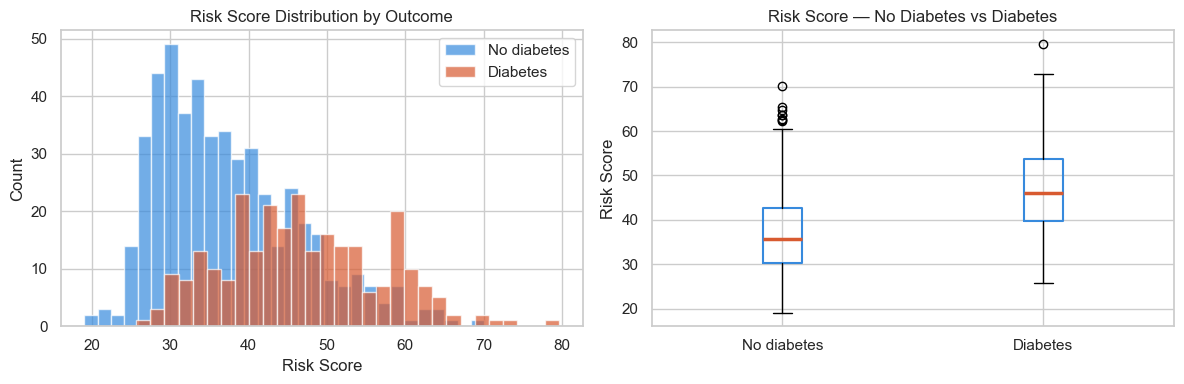

✓ Risk_score column created


In [36]:
# Composite risk score — weighted combination of key risk factors
# Each component contributes a maximum of 100, then we scale to 0-100 overall
# Weights are based on clinical importance of each factor for diabetes

df["Risk_score"] = (
    (df["Pregnancies"]   / df["Pregnancies"].max()   * 40) +
    (df["Glucose"]   / df["Glucose"].max()   * 30) +
    (df["BloodPressure"] / df["BloodPressure"].max() * 15) +
    (df["SkinThickness"] / df["SkinThickness"].max() * 15)
).round(2)

print(f"Risk score range : {df['Risk_score'].min():.2f} — {df['Risk_score'].max():.2f}")
print(f"Mean risk score  : {df['Risk_score'].mean():.2f}")
print()

# How does risk score differ between diabetic and non-diabetic?
print("Average risk score by outcome:")
print(df.groupby('Outcome')['Risk_score'].mean().round(2))
print()

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df[df['Outcome']==0]['Risk_score'], bins=30,
             alpha=0.7, color='#378ADD', label='No diabetes', edgecolor='white')
axes[0].hist(df[df['Outcome']==1]['Risk_score'], bins=30,
             alpha=0.7, color='#D85A30', label='Diabetes', edgecolor='white')
axes[0].set_title('Risk Score Distribution by Outcome')
axes[0].set_xlabel('Risk Score')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].boxplot(
    [df[df['Outcome']==0]['Risk_score'],
     df[df['Outcome']==1]['Risk_score']],
    labels=['No diabetes', 'Diabetes'],
    boxprops=dict(color='#378ADD', linewidth=1.5),
    medianprops=dict(color='#D85A30', linewidth=2.5)
)
axes[1].set_title('Risk Score — No Diabetes vs Diabetes')
axes[1].set_ylabel('Risk Score')

plt.tight_layout()
plt.savefig('../outputs/risk_score_distribution.png', dpi=150)
plt.show()
print("✓ Risk_score column created")

The diabetic group should have a clearly higher average risk score than the non-diabetic group. If the two distributions overlap a lot it means the weights need adjusting — we can tune them later.

---
## Step 3 — Encode Categorical Columns

ML models only understand numbers — not text like `'Obese'` or `'Senior'`.  
We convert the new text columns into numeric codes using LabelEncoder.

| Column | Before | After |
|---|---|---|
| BMI_category | 'Normal', 'Obese'... | 0, 1, 2, 3 |
| Age_group | 'Young', 'Middle'... | 0, 1, 2 |
| Glucose_level | 'Normal', 'Prediabetic'... | 0, 1, 2 |

We save each encoder to `models/` so the Streamlit app can  
convert user input text back to numbers consistently later.

In [37]:
os.makedirs('../models', exist_ok=True)

cat_cols = ['BMI_category', 'Age_group', 'Glucose_level']
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

    # Show the mapping so it's transparent
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"{col} mapping: {mapping}")

# Save all encoders in one file
joblib.dump(encoders, '../models/label_encoders.pkl')
print("\nEncoders saved -> models/label_encoders.pkl")
print(f"\nDataset shape after encoding: {df.shape}")
df.head(3)

BMI_category mapping: {'Normal': np.int64(0), 'Obese': np.int64(1), 'Overweight': np.int64(2), 'Underweight': np.int64(3)}
Age_group mapping: {'Middle': np.int64(0), 'Senior': np.int64(1), 'Young': np.int64(2)}
Glucose_level mapping: {'Diabetic_range': np.int64(0), 'Normal': np.int64(1), 'Prediabetic': np.int64(2)}

Encoders saved -> models/label_encoders.pkl

Dataset shape after encoding: (768, 13)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_category,Age_group,Glucose_level,Risk_score
0,6,148.0,72.0,35.00000,155.548223,33.6,0.627,50,1,1,0,0,50.58
1,1,85.0,66.0,29.00000,155.548223,26.6,0.351,31,0,2,0,1,27.68
2,8,183.0,64.0,29.15342,155.548223,23.3,0.672,32,1,0,0,0,58.70


Each column now shows numbers instead of text. The mapping printout tells you exactly which number means which category — important to keep track of so results are interpretable later.

---
## Step 4 — Scale Numeric Features

Most ML algorithms measure distance or use gradients.  
If one column has values 0–200 (Glucose) and another has  
values 0–2 (DiabetesPedigreeFunction), the large-scale column  
will dominate the model unfairly.

StandardScaler fixes this by converting every column to  
**mean = 0, standard deviation = 1**.
```
Original Glucose : 148  →  Scaled : +1.24
Original Glucose :  85  →  Scaled : -0.88
```

**Important rule — fit on training data only.**  
If we fit the scaler on the whole dataset, information from  
the test set leaks into training. We split first, then scale.

In [38]:
from sklearn.model_selection import train_test_split

# Separate features and BOTH targets
# Risk_score is kept SEPARATE — it will NOT be scaled
# Outcome is the classification target
X       = df.drop(columns=["Outcome", "Risk_score"])  # features only
y_class = df["Outcome"]      # classification target (0/1)
y_reg   = df["Risk_score"]   # regression target (0-100) — kept unscaled

# Split stratified on classification target
X_train, X_test, y_train_c, y_test_c = train_test_split(
    X, y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

# Split regression target using same row indices
y_train_r = y_reg.loc[y_train_c.index].reset_index(drop=True)
y_test_r  = y_reg.loc[y_test_c.index].reset_index(drop=True)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"Risk score — ORIGINAL scale (not scaled):")
print(f"  Min  : {y_train_r.min():.2f}")
print(f"  Max  : {y_train_r.max():.2f}")
print(f"  Mean : {y_train_r.mean():.2f}")
print(f"Class balance in train:")
print(y_train_c.value_counts(normalize=True).round(3))
print(f"Class balance in test:")
print(y_test_c.value_counts(normalize=True).round(3))


X_train : (614, 11)
X_test  : (154, 11)
Risk score — ORIGINAL scale (not scaled):
  Min  : 19.06
  Max  : 79.64
  Mean : 40.61
Class balance in train:
Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64
Class balance in test:
Outcome
0    0.649
1    0.351
Name: proportion, dtype: float64


Both train and test should show approximately the same 65/35 class balance. This is what stratify=y ensures — without it, you might get an unlucky split where all the diabetic patients end up in training and none in test.

In [39]:
# Fit scaler ONLY on training data
# Risk_score is NOT in X_train — it stays in its original 0-100 range
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)  # transform only — do NOT fit again

# Convert back to DataFrame so column names are preserved
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test.columns)

# Save the fitted scaler
joblib.dump(scaler, "G:/healthcare/models/feature_scaler.pkl")

print("Before scaling — Glucose column:")
print(f"  Mean : {X_train['Glucose'].mean():.2f}")
print(f"  Std  : {X_train['Glucose'].std():.2f}")

print("After scaling — Glucose column:")
print(f"  Mean : {X_train_scaled['Glucose'].mean():.4f}  <- close to 0")
print(f"  Std  : {X_train_scaled['Glucose'].std():.4f}   <- close to 1")

print("Risk_score column — check it is NOT scaled:")
print(f"  y_train_r min : {y_train_r.min():.2f}")
print(f"  y_train_r max : {y_train_r.max():.2f}")
print(f"  y_train_r mean: {y_train_r.mean():.2f}")
print("Scaler saved: G:/healthcare/models/feature_scaler.pkl")


Before scaling — Glucose column:
  Mean : 121.70
  Std  : 30.00
After scaling — Glucose column:
  Mean : -0.0000  <- close to 0
  Std  : 1.0008   <- close to 1
Risk_score column — check it is NOT scaled:
  y_train_r min : 19.06
  y_train_r max : 79.64
  y_train_r mean: 40.61
Scaler saved: G:/healthcare/models/feature_scaler.pkl


After scaling, Glucose mean should be very close to 0.0000 and std very close to 1.0000. That confirms the scaler worked correctly.

In [40]:
# Build train and test DataFrames
# Scaled features + unscaled Risk_score + Outcome
train_final = X_train_scaled.copy()
train_final["Risk_score"] = y_train_r.values  # original 0-100 scale
train_final["Outcome"]    = y_train_c.values

test_final = X_test_scaled.copy()
test_final["Risk_score"] = y_test_r.values    # original 0-100 scale
test_final["Outcome"]    = y_test_c.values

# Save to your actual project path
BASE = "G:/healthcare/Dataset/processed"

train_final.to_csv(f"{BASE}/pima_train.csv", index=False)
test_final.to_csv(f"{BASE}/pima_test.csv",   index=False)
df.to_csv(f"{BASE}/pima_features.csv",        index=False)

print("Files saved:")
print(f"  pima_train.csv    {train_final.shape}")
print(f"  pima_test.csv     {test_final.shape}")
print(f"  pima_features.csv {df.shape}")

print("Columns in pima_train.csv:")
print(list(train_final.columns))

print("Risk_score in saved file — should be 0-100:")
print(f"  Min  : {train_final['Risk_score'].min():.2f}")
print(f"  Max  : {train_final['Risk_score'].max():.2f}")
print(f"  Mean : {train_final['Risk_score'].mean():.2f}")

print("Models folder:")
for f in os.listdir("G:/healthcare/models"):
    print(f"  - {f}")


Files saved:
  pima_train.csv    (614, 13)
  pima_test.csv     (154, 13)
  pima_features.csv (768, 13)
Columns in pima_train.csv:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'BMI_category', 'Age_group', 'Glucose_level', 'Risk_score', 'Outcome']
Risk_score in saved file — should be 0-100:
  Min  : 19.06
  Max  : 79.64
  Mean : 40.61
Models folder:
  - feature_scaler.pkl
  - knn_recommender.pkl
  - label_encoders.pkl
  - recommendation_scaler.pkl


---
## Feature Engineering Summary

### New features created
| Feature | Type | Built from |
|---|---|---|
| BMI_category | Categorical | BMI — WHO thresholds |
| Age_group | Categorical | Age — Young / Middle / Senior |
| Glucose_level | Categorical | Glucose — ADA clinical thresholds |
| Risk_score | Numeric | Weighted composite of 5 columns |

### Processing applied
| Step | Method | Why |
|---|---|---|
| Encoding | LabelEncoder | Models need numbers not text |
| Scaling | StandardScaler | Equal feature importance |
| Split | 80/20 stratified | Preserve class balance |

### Files saved
- `data/processed/pima_train.csv` — scaled training set
- `data/processed/pima_test.csv`  — scaled test set
- `data/processed/pima_features.csv` — full engineered dataset
- `models/feature_scaler.pkl` — fitted scaler
- `models/label_encoders.pkl` — fitted encoders

---
**Next notebook → `04_regression.ipynb`**